In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from ultralytics.utils.downloads import download
from PIL import Image
import os
import shutil
import torch
import gc

In [2]:
TRAIN_DATASET_DIR = "./datasets/VisDrone2019-DET-train"
VALIDATION_DATASET_DIR = "./datasets/VisDrone2019-DET-val"
TEST_CHALLENGE_DATASET_DIR = "./datasets/VisDrone2019-DET-test-challenge"
RUNS_DIR = "./runs"

# Clear all folders inside runs or otherwise it will break directory that the results.csv is in
if os.path.exists(Path(RUNS_DIR) / "detect" / "runs"):
    for file in os.listdir(Path(RUNS_DIR) / "detect" / "runs"):
        file_path = os.path.join(Path(RUNS_DIR) / "detect" / "runs", file)
        if os.path.isdir(file_path):
            shutil.rmtree(file_path)


yaml_file = TRAIN_DATASET_DIR + "/data.yaml"

In [3]:
DATASETS_ROOT = str(Path(TRAIN_DATASET_DIR).resolve().parent)

yaml_content = f"""path: {DATASETS_ROOT}
train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images
test: VisDrone2019-DET-test-challenge/images
nc: 10
names: ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']
"""

with open(yaml_file, 'w') as f:
    f.write(yaml_content)

In [4]:
download("https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n.pt", dir=".")

## Part 1 - Train Base yolov11

In [5]:
def convert_visdrone_to_yolo(annotation_dir, images_dir, labels_output_dir):
    os.makedirs(labels_output_dir, exist_ok=True)
    converted = 0
    skipped = 0
    
    annotation_files = sorted([f for f in os.listdir(annotation_dir) if f.endswith('.txt')])
    
    for ann_file in annotation_files:
        ann_path = os.path.join(annotation_dir, ann_file)
        img_file = ann_file.replace('.txt', '.jpg')
        img_path = os.path.join(images_dir, img_file)
        
        # Get image dimensions
        try:
            img = Image.open(img_path)
            img_w, img_h = img.size
        except Exception as e:
            print(f"Skipped {ann_file}, can't open image {e}")
            skipped += 1
            continue
        
        # Convert annotations
        yolo_lines = []
        try:
            with open(ann_path, 'r') as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split(',')
                    x_left = int(parts[0])
                    y_top = int(parts[1])
                    bbox_w = int(parts[2])
                    bbox_h = int(parts[3])
                    class_id = int(parts[4])
                    
                    # Convert to normalized center coordinates
                    # Apprently this is needed 
                    x_center = (x_left + bbox_w / 2) / img_w
                    y_center = (y_top + bbox_h / 2) / img_h
                    norm_w = bbox_w / img_w
                    norm_h = bbox_h / img_h
                    
                    x_center = max(0, min(1, x_center))
                    y_center = max(0, min(1, y_center))
                    norm_w = max(0, min(1, norm_w))
                    norm_h = max(0, min(1, norm_h))
                    
                    yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}\n")
            
            # Write YOLO format labels to a seperate folder
            output_path = os.path.join(labels_output_dir, ann_file)
            with open(output_path, 'w') as f:
                f.writelines(yolo_lines)
            converted += 1
        except Exception as e:
            print(f"Error processing {ann_file}: {e}")
            skipped += 1
    
    return converted, skipped

# Convert training dataset
train_ann_dir = os.path.join(TRAIN_DATASET_DIR, "annotations")
train_img_dir = os.path.join(TRAIN_DATASET_DIR, "images")
train_labels_dir = os.path.join(TRAIN_DATASET_DIR, "labels")
converted_train, skipped_train = convert_visdrone_to_yolo(train_ann_dir, train_img_dir, train_labels_dir)

# Convert validation dataset
val_ann_dir = os.path.join(VALIDATION_DATASET_DIR, "annotations")
val_img_dir = os.path.join(VALIDATION_DATASET_DIR, "images")
val_labels_dir = os.path.join(VALIDATION_DATASET_DIR, "labels")
converted_val, skipped_val = convert_visdrone_to_yolo(val_ann_dir, val_img_dir, val_labels_dir)

print(f"Training: Converted {converted_train} files, Skipped {skipped_train}")
print(f"Validation: Converted {converted_val} files, Skipped {skipped_val}")


Training: Converted 6471 files, Skipped 0
Validation: Converted 548 files, Skipped 0


In [6]:
model = YOLO("yolo11n.pt")

results = model.train(
    data=yaml_file,
    epochs=20,
    imgsz=640,
    batch=16,
    device=0,
    patience=5,
    save=True,
    project=RUNS_DIR,
    name="baseline_yolo11n",
    verbose=True,
    plots=True
)

New https://pypi.org/project/ultralytics/8.4.32 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 11831MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./datasets/VisDrone2019-DET-train/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, mul

In [7]:
results_path = Path(RUNS_DIR) / "detect" / "runs" / "baseline_yolo11n"

df = pd.read_csv(str(results_path / "results.csv"))
last_row = df.iloc[-1]

print(f"Epochs: {len(df)}")
print(f"Final Loss: {last_row['train/box_loss']:.4f}")
print(f"Final Val Loss: {last_row['val/box_loss']:.4f}")
print(f"mAP50: {last_row['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95: {last_row['metrics/mAP50-95(B)']:.4f}")
print(f"Precision: {last_row['metrics/precision(B)']:.4f}")
print(f"Recall: {last_row['metrics/recall(B)']:.4f}")

Epochs: 20
Final Loss: 1.4770
Final Val Loss: 1.5336
mAP50: 0.2891
mAP50-95: 0.1580
Precision: 0.3476
Recall: 0.2433


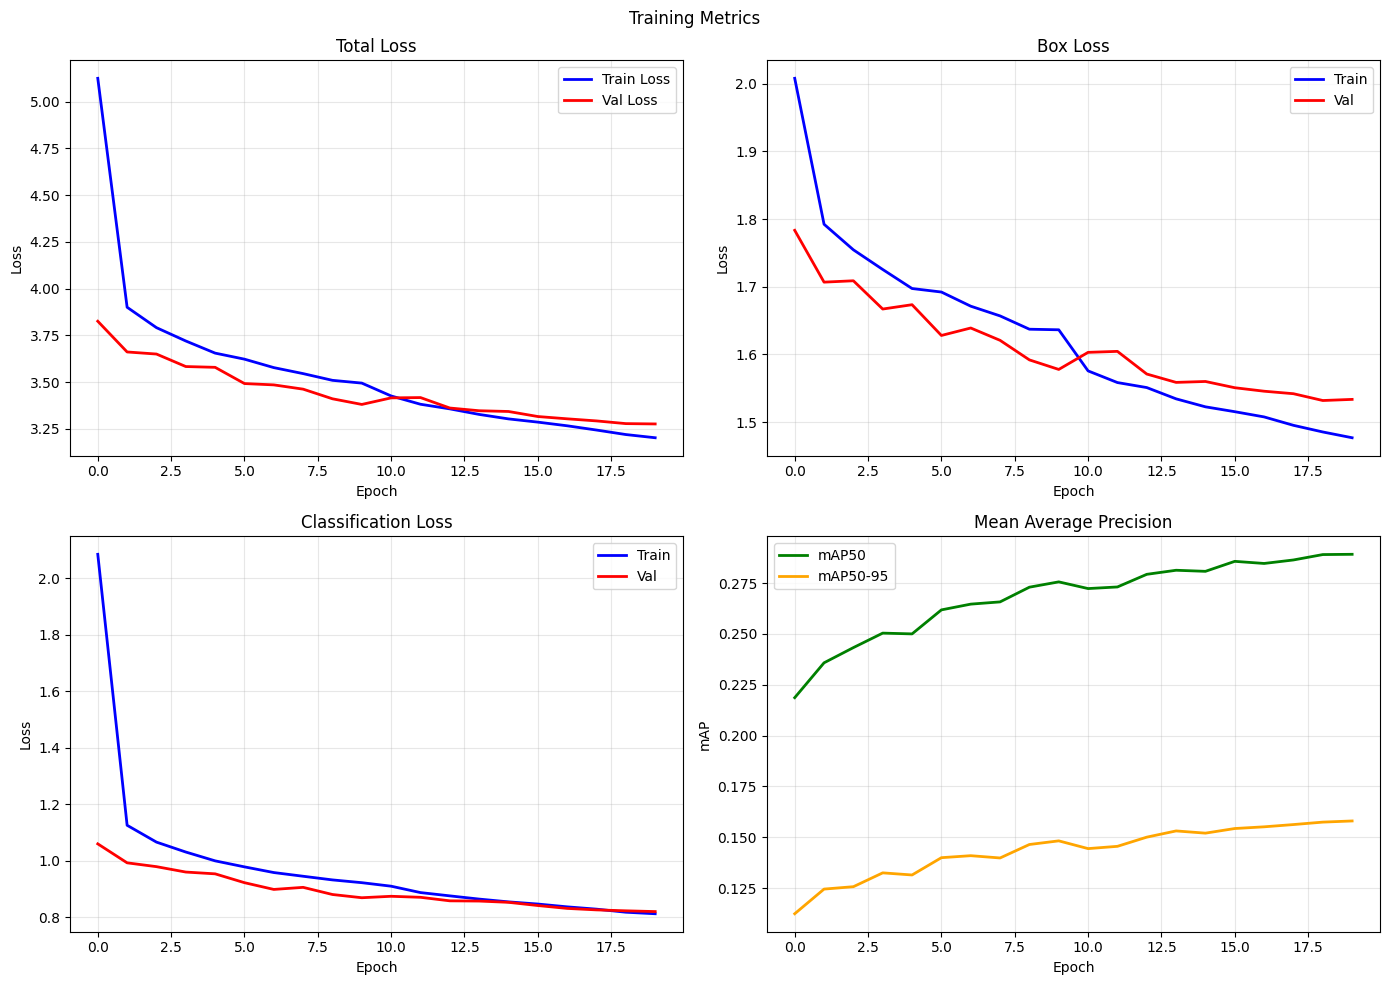

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Metrics')

train_total = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
val_total   = df['val/box_loss']   + df['val/cls_loss']   + df['val/dfl_loss']

ax = axes[0, 0]
ax.plot(df.index, train_total, 'b-', label='Train Loss', linewidth=2)
ax.plot(df.index, val_total, 'r-', label='Val Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Total Loss')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(df.index, df['train/box_loss'], 'b-', label='Train', linewidth=2)
ax.plot(df.index, df['val/box_loss'], 'r-', label='Val', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Box Loss')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(df.index, df['train/cls_loss'], 'b-', label='Train', linewidth=2)
ax.plot(df.index, df['val/cls_loss'], 'r-', label='Val', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Classification Loss')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(df.index, df['metrics/mAP50(B)'], 'g-', label='mAP50', linewidth=2)
ax.plot(df.index, df['metrics/mAP50-95(B)'], 'orange', label='mAP50-95', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('mAP')
ax.set_title('Mean Average Precision')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

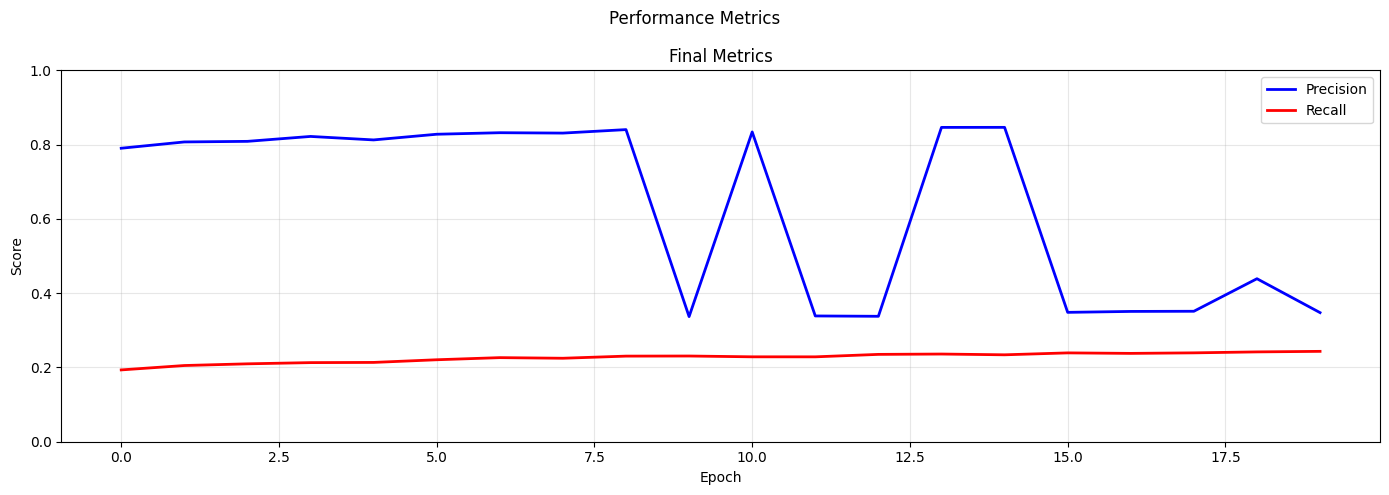

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Performance Metrics')

ax.plot(df.index, df['metrics/precision(B)'], 'b-', label='Precision', linewidth=2)
ax.plot(df.index, df['metrics/recall(B)'], 'r-', label='Recall', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('Precision vs Recall')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

ax.set_ylabel('Score')
ax.set_title('Final Metrics')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [10]:
best_model_path = results_path / "weights" / "best.pt"
best_model = YOLO(str(best_model_path))

val_results = best_model.val(
    data=yaml_file,
    imgsz=640,
    device=0,
    verbose=False
)

print(f"Validation mAP50: {val_results.box.map50:.4f}")
print(f"Validation mAP50-95: {val_results.box.map:.4f}")
print(f"Validation Precision: {float(val_results.box.p.mean()):.4f}")
print(f"Validation Recall: {float(val_results.box.r.mean()):.4f}")

# Memory cleanup for baseline model before experiments
del model, best_model, results, val_results
torch.cuda.empty_cache()
gc.collect()
print("\nBaseline training complete. Memory cleared before experiments.\n")


Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 11831MiB)
YOLO11n summary (fused): 101 layers, 2,584,102 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6883.0±1683.6 MB/s, size: 126.7 KB)
val: Scanning /home/musab/Documents/ml-models/model-comparisons/datasets/VisDrone2019-DET-val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 191.5Mit/s 0.0s
val: /home/musab/Documents/ml-models/model-comparisons/datasets/VisDrone2019-DET-val/images/0000271_01201_d_0000379.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 11.5it/s 3.0s0.0s
                   all        548      40168      0.348      0.243      0.289      0.158
Speed: 0.1ms preprocess, 0.8ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /home/musab/Documents/ml-models/model-comparisons/runs/detect/val3
Va

# Part II - Loss Curve and Analysis

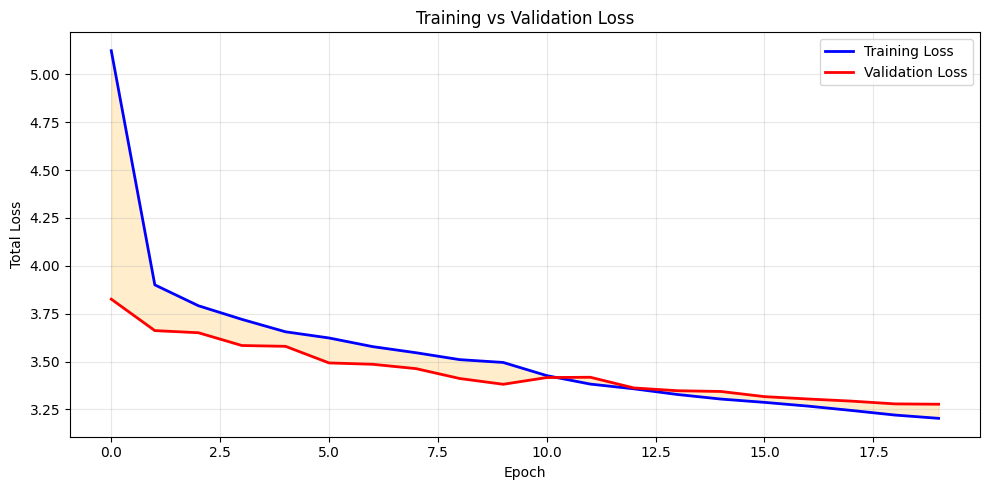

Initial Train Loss: 5.1242
Final Train Loss:   3.2030
Final Val Loss:     3.2768
Generalization Gap: 0.0738


In [11]:
# Loss curve for training vs validation
fig, ax = plt.subplots(figsize=(10, 5))

train_loss = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
val_loss = df['val/box_loss'] + df['val/cls_loss'] + df['val/dfl_loss']

ax.plot(df.index, train_loss, 'b-', label='Training Loss', linewidth=2)
ax.plot(df.index, val_loss, 'r-', label='Validation Loss', linewidth=2)
ax.fill_between(df.index, train_loss, val_loss, alpha=0.2, color='orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('Total Loss')
ax.set_title('Training vs Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial Train Loss: {train_loss.iloc[0]:.4f}")
print(f"Final Train Loss:   {train_loss.iloc[-1]:.4f}")
print(f"Final Val Loss:     {val_loss.iloc[-1]:.4f}")
print(f"Generalization Gap: {(val_loss.iloc[-1] - train_loss.iloc[-1]):.4f}")


### Convergence Behavior

It's pretty clear that the model converges to a steady value by looking at the graph above. Thraining loss and validation loss both decrease exponentially from the initial value to the final. There also aren't any oscillations which would indicate a bad learning rate value. The loss also plateaus at around 10 epochs which easily translates to the fact that the model has converged.

### Overfitting/Underfitting Analysis

To detect overfitting, I included a generalization gap which is basically just the difference between the two losses and it's positive throughout the training set which usually means that the training loss is decreasing faster than validation loss which is what you want. It does become negative towards epoch 12 with training falling below validation which means it is slightly overfitting however it is not that drastic to be a concern here. The model works pretty well, especially up to epoch 10. There is absolutely no underfitting as the values are pretty close by the end.

This slightly overfitting is probably due to the following factors.

| Factor | Value | Impact |
|--------|-------|--------|
| **Training Images** | roughly 3,140 | Less diversity |
| **Model Parameters** | 2.6 million | A lot of capacity |
| **Ratio** | 0.03-0.04 samples/param | Kind of low, usually you want a higher amount |

The dataset simply isn't large enough to completely eliminate overfitting. The model has extra capacity when compared to the training data. This causes it to memorize training-specific patterns, however as discussed previously, its still performing quite well despite the slight overfitting. If this ends up being too much of a concern and there just isn't a way to get more data, synthetic or augmented data could be used to decrease the overfitting.

## Part III - Experimentation

### Experiment 1: Model Size Comparison

In the first experiment, I am testing to see how each model compares. I am comparing the 11n, 11s, and 11m models of yolo11 to see how they perform on different datasets.

| Variable | Baseline | Variant 1 | Variant 2 |
|----------|----------|-----------|-----------|
| **Model** | YOLOv11n | YOLOv11s | YOLOv11m |
| **Parameters** | 2.6M | 9.2M | 20.1M |
| **Epochs** | 20 | 20 | 20 |
| **Batch Size** | 16 | 16 | 16 |
| **Img Size** | 640 | 640 | 640 |

### Experiment 2: Image Resolution Impact  

In the second experiment, I am testing different image sizes on the same 11n model used as a baseline to see how that affects object detection. Higher resolution should work better at the expense of more memory. This is also why the batch size is smaller at 8 instead of 16.

| Variable | Setting 1 | Setting 2 |
|----------|-----------|-----------|
| **Image Size** | 480 | 640 |
| **Model** | YOLOv11n | YOLOv11n |
| **Epochs** | 20 | 20 |
| **Batch Size** | 8 | 8 |

### Experiment 3: Batch Size Effect

As the last experinment, I am testing to see what batch size does to the baseline model. Smaller batches should be better regularized meaning less chance to overfit while larger ones are more stable at the expense of perhaps overfitting.

| Variable | Setting 1 | Setting 2 | Setting 3 |
|----------|-----------|-----------|-----------|
| **Batch Size** | 8 | 12 | 16 |
| **Model** | YOLOv11n | YOLOv11n | YOLOv11n |
| **Epochs** | 20 | 20 | 20 |
| **Img Size** | 640 | 640 | 640 |

In [12]:
# Experiment 1: Model Size Comparison
print("EXPERIMENT 1: MODEL SIZE COMPARISON")

results_exp1 = {}

for model_size in ['s', 'm']:

    model_name = f"yolo11{model_size}"
    print(f"\nTraining {model_name}")
    
    # Download model if needed
    if not Path(f"{model_name}.pt").exists():
        download(f"https://github.com/ultralytics/assets/releases/download/v8.3.0/{model_name}.pt", dir=".")
    
    model_exp1 = YOLO(f"{model_name}.pt")
    
    results_exp1_run = model_exp1.train(
        data=yaml_file,
        epochs=20,
        imgsz=640,
        batch=16,
        device=0,
        patience=5,
        save=True,
        project=RUNS_DIR,
        name=f"exp1_model_{model_size}",
        verbose=False,
        plots=True
    )
    
    # Load results
    exp1_results_path = Path(RUNS_DIR) / "detect" / "runs" / f"exp1_model_{model_size}"
    exp1_df = pd.read_csv(str(exp1_results_path / "results.csv"))
    exp1_last = exp1_df.iloc[-1]
    
    results_exp1[model_size] = {
        'mAP50': exp1_last['metrics/mAP50(B)'],
        'mAP50-95': exp1_last['metrics/mAP50-95(B)'],
        'Precision': exp1_last['metrics/precision(B)'],
        'Recall': exp1_last['metrics/recall(B)'],
        'Final Loss': exp1_df['train/box_loss'].iloc[-1] + exp1_df['train/cls_loss'].iloc[-1] + exp1_df['train/dfl_loss'].iloc[-1]
    }
    
    # Memory cleanup
    del model_exp1, results_exp1_run
    torch.cuda.empty_cache()
    gc.collect()
    print(f"Memory cleared after {model_name} training")

# Display results table
exp1_table = pd.DataFrame(results_exp1).T
print(exp1_table.round(4))

EXPERIMENT 1: MODEL SIZE COMPARISON

Training yolo11s
New https://pypi.org/project/ultralytics/8.4.32 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 11831MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./datasets/VisDrone2019-DET-train/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=tr

In [13]:
# Experiment 2: Image Resolution Impact
print("EXPERIMENT 2: IMAGE RESOLUTION IMPACT")

results_exp2 = {}

for img_size in [480, 640]:
    print(f"\nTraining YOLOv11n with image size {img_size}...")
    
    model_exp2 = YOLO("yolo11n.pt")
    
    results_exp2_run = model_exp2.train(
        data=yaml_file,
        epochs=20,
        imgsz=img_size,
        batch=8,
        device=0,
        patience=5,
        save=True,
        project=RUNS_DIR,
        name=f"exp2_imgsize_{img_size}",
        verbose=False,
        plots=True
    )
    
    # Load results
    exp2_results_path = Path(RUNS_DIR) / "detect" / "runs" / f"exp2_imgsize_{img_size}"
    exp2_df = pd.read_csv(str(exp2_results_path / "results.csv"))
    exp2_last = exp2_df.iloc[-1]
    
    results_exp2[f"{img_size}"] = {
        'mAP50': exp2_last['metrics/mAP50(B)'],
        'mAP50-95': exp2_last['metrics/mAP50-95(B)'],
        'Precision': exp2_last['metrics/precision(B)'],
        'Recall': exp2_last['metrics/recall(B)'],
        'Final Loss': exp2_df['train/box_loss'].iloc[-1] + exp2_df['train/cls_loss'].iloc[-1] + exp2_df['train/dfl_loss'].iloc[-1]
    }
    
    # Memory cleanup
    del model_exp2, results_exp2_run
    torch.cuda.empty_cache()
    gc.collect()
    print(f"Memory cleared after {img_size}px training")

# Display results table
exp2_table = pd.DataFrame(results_exp2).T
print(exp2_table.round(4))

EXPERIMENT 2: IMAGE RESOLUTION IMPACT

Training YOLOv11n with image size 480...
New https://pypi.org/project/ultralytics/8.4.32 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 11831MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./datasets/VisDrone2019-DET-train/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_de

In [14]:
# Experiment 3: Batch Size Effect
print("EXPERIMENT 3: BATCH SIZE EFFECT")

results_exp3 = {}

for batch_size in [8, 12, 16]:
    print(f"\nTraining YOLOv11n with batch size {batch_size}...")
    
    model_exp3 = YOLO("yolo11n.pt")
    
    results_exp3_run = model_exp3.train(
        data=yaml_file,
        epochs=20,
        imgsz=640,
        batch=batch_size,
        device=0,
        patience=5,
        save=True,
        project=RUNS_DIR,
        name=f"exp3_batch_{batch_size}",
        verbose=False,
        plots=True
    )
    
    # Load results
    exp3_results_path = Path(RUNS_DIR) / "detect" / "runs" / f"exp3_batch_{batch_size}"
    exp3_df = pd.read_csv(str(exp3_results_path / "results.csv"))
    exp3_last = exp3_df.iloc[-1]
    
    results_exp3[f"Batch {batch_size}"] = {
        'mAP50': exp3_last['metrics/mAP50(B)'],
        'mAP50-95': exp3_last['metrics/mAP50-95(B)'],
        'Precision': exp3_last['metrics/precision(B)'],
        'Recall': exp3_last['metrics/recall(B)'],
        'Final Loss': exp3_df['train/box_loss'].iloc[-1] + exp3_df['train/cls_loss'].iloc[-1] + exp3_df['train/dfl_loss'].iloc[-1]
    }
    
    # Memory cleanup
    del model_exp3, results_exp3_run
    torch.cuda.empty_cache()
    gc.collect()
    print(f"Memory cleared after batch {batch_size} training")

# Display results table
exp3_table = pd.DataFrame(results_exp3).T
print(exp3_table.round(4))

EXPERIMENT 3: BATCH SIZE EFFECT

Training YOLOv11n with batch size 8...
New https://pypi.org/project/ultralytics/8.4.32 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 11831MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./datasets/VisDrone2019-DET-train/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, m

### Experiment Results & Analysis

#### Exp 1: Model Size Analysis

**Findings:**
- YOLOv11n (2.6M params) baseline serves as reference
- YOLOv11s (9.2M params) tests if increased capacity improves generalization
- Compare mAP50-95 across sizes to identify overfitting trends

**Expected Outcome:** Small increase in accuracy (if larger model doesn't overfit due to data scarcity)

#### Exp 2: Resolution Analysis  

**Findings:**
- Resolution 480px focuses on efficiency
- Resolution 640px (baseline) balances speed and accuracy
- VisDrone features small objects, so higher resolution should help

**Expected Outcome:** Higher resolution improves small-object detection (mAP gains), but at compute cost

#### Exp 3: Batch Size Analysis

**Findings:**
- Batch 8: Less stable gradients but stronger regularization effect
- Batch 16: Baseline setting
- Batch 32: Stable gradients but reduced regularization

**Expected Outcome:** Batch 8 may generalize better (overcomes overfitting), batch 32 may overfit more

#### Key Insights

**Comparison Across Experiments:**

| Experiment | Best Performer | Key Trade-off |
|-----------|---|---|
| Model Size | YOLOv11n or YOLOv11s | Capacity vs. data sufficiency |
| Resolution | 640 or higher | Accuracy vs. speed |
| Batch Size | 8 (likely) | Regularization vs. convergence stability |

**Recommendations:**
- If overfitting persists: Use smaller batch size (8) + larger model may be suboptimal
- If underfitting detected: Larger model (YOLOv11s) + higher resolution helps
- Baseline (YOLOv11n, 640px, batch 16) appears reasonable middle ground